In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("salary_task1_cleaned.csv")
df["survey_date"] = pd.to_datetime(df["survey_date"])

In [2]:
print(df["survey_date"].dtype)

datetime64[us]


In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (2000, 18)


In [4]:
print("Columns:")
print(df.columns.tolist())

Columns:
['age', 'gender', 'education', 'experience_years', 'role_seniority', 'company_size', 'location_tier', 'skills_count', 'certifications', 'worked_remote', 'last_promotion_years_ago', 'salary_bdt', 'recent_project_description_length', 'survey_date', 'recent_note', 'survey_year', 'survey_month', 'role_seniority_encoded']


In [5]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
age                                    0
gender                                 0
education                            100
experience_years                     160
role_seniority                         0
company_size                           0
location_tier                          0
skills_count                         200
certifications                        80
worked_remote                          0
last_promotion_years_ago             120
salary_bdt                             0
recent_project_description_length    240
survey_date                            0
recent_note                          300
survey_year                            0
survey_month                           0
role_seniority_encoded                 0
dtype: int64


In [6]:
numeric_columns = [
    "age",
    "experience_years",
    "skills_count",
    "certifications",
    "worked_remote",
    "last_promotion_years_ago",
    "salary_bdt",
    "recent_project_description_length"
]

print("Numerical Columns:")
print(numeric_columns)

Numerical Columns:
['age', 'experience_years', 'skills_count', 'certifications', 'worked_remote', 'last_promotion_years_ago', 'salary_bdt', 'recent_project_description_length']


In [7]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
age,2000.0,30.367500,5.721172,20.0,26.00,30.0,34.0,53.0
experience_years,1840.0,7.729348,5.676872,0.0,3.00,7.0,11.0,29.0
skills_count,1800.0,5.043333,2.211021,1.0,4.00,5.0,6.0,14.0
certifications,1920.0,1.008333,0.996049,0.0,0.00,1.0,2.0,7.0
worked_remote,2000.0,0.384500,0.486599,0.0,0.00,0.0,1.0,1.0
last_promotion_years_ago,1880.0,2.117021,1.968925,0.0,1.00,2.0,3.0,7.0
salary_bdt,2000.0,117278.899000,55237.215743,23238.0,77350.25,111433.5,147821.0,612816.0
recent_project_description_length,1760.0,59.056250,9.697864,31.0,52.00,59.0,66.0,93.0


In [8]:
print("Dataset Shape:", df.shape)
print(df["survey_date"].dtype)
print(df.isnull().sum())

Dataset Shape: (2000, 18)
datetime64[us]
age                                    0
gender                                 0
education                            100
experience_years                     160
role_seniority                         0
company_size                           0
location_tier                          0
skills_count                         200
certifications                        80
worked_remote                          0
last_promotion_years_ago             120
salary_bdt                             0
recent_project_description_length    240
survey_date                            0
recent_note                          300
survey_year                            0
survey_month                           0
role_seniority_encoded                 0
dtype: int64


In [9]:
numeric_columns = [
    "age",
    "experience_years",
    "skills_count",
    "certifications",
    "worked_remote",
    "last_promotion_years_ago",
    "salary_bdt",
    "recent_project_description_length"
]

In [10]:
statistics = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Mode": [
        df[col].mode(dropna=True).iloc[0]
        if not df[col].mode(dropna=True).empty
        else np.nan
        for col in numeric_columns
    ]
})

statistics

,Mean,Median,Mode
age,30.367500,30.0,30.0
experience_years,7.729348,7.0,0.0
skills_count,5.043333,5.0,4.0
certifications,1.008333,1.0,1.0
worked_remote,0.384500,0.0,0.0
last_promotion_years_ago,2.117021,2.0,0.0
salary_bdt,117278.899000,111433.5,44834.0
recent_project_description_length,59.056250,59.0,53.0


In [11]:
df[numeric_columns].mean()

age                                      30.367500
experience_years                          7.729348
skills_count                              5.043333
certifications                            1.008333
worked_remote                             0.384500
last_promotion_years_ago                  2.117021
salary_bdt                           117278.899000
recent_project_description_length        59.056250
dtype: float64

In [12]:
df[numeric_columns].median()

age                                      30.0
experience_years                          7.0
skills_count                              5.0
certifications                            1.0
worked_remote                             0.0
last_promotion_years_ago                  2.0
salary_bdt                           111433.5
recent_project_description_length        59.0
dtype: float64

In [14]:
mode_values = {}

for col in numeric_columns:
    mode = df[col].mode(dropna=True)
    
    if not mode.empty:
        mode_values[col] = mode.iloc[0]
    else:
        mode_values[col] = np.nan

mode_values

{'age': np.int64(30),
 'experience_years': np.float64(0.0),
 'skills_count': np.float64(4.0),
 'certifications': np.float64(1.0),
 'worked_remote': np.int64(0),
 'last_promotion_years_ago': np.float64(0.0),
 'salary_bdt': np.int64(44834),
 'recent_project_description_length': np.float64(53.0)}

In [15]:
dropna=True

In [16]:
statistics = statistics.round(2)
statistics

,Mean,Median,Mode
age,30.37,30.0,30.0
experience_years,7.73,7.0,0.0
skills_count,5.04,5.0,4.0
certifications,1.01,1.0,1.0
worked_remote,0.38,0.0,0.0
last_promotion_years_ago,2.12,2.0,0.0
salary_bdt,117278.90,111433.5,44834.0
recent_project_description_length,59.06,59.0,53.0


In [17]:
salary_stats = statistics.loc["salary_bdt"]

print("Salary Mean:", salary_stats["Mean"])
print("Salary Median:", salary_stats["Median"])
print("Salary Mode:", salary_stats["Mode"])

Salary Mean: 117278.9
Salary Median: 111433.5
Salary Mode: 44834.0


In [18]:
gender_stats = df.groupby("gender")["salary_bdt"].agg(
    Mean="mean",
    Median="median",
    Mode=lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
).round(2)

gender_stats

,Mean,Median,Mode
gender,,,
Female,120047.51,116376.0,27649
Male,116194.60,110159.0,44834
Other,120029.73,127921.0,37063


In [19]:
seniority_stats = df.groupby("role_seniority")["salary_bdt"].agg(
    Mean="mean",
    Median="median",
    Mode=lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
).round(2)

seniority_stats

,Mean,Median,Mode
role_seniority,,,
Junior,106767.44,104171.0,131240
Lead,146088.85,140385.0,56662
Mid,116393.54,111207.0,55229
Senior,130780.68,128333.0,42955


In [20]:
company_stats = df.groupby("company_size")["salary_bdt"].agg(
    Mean="mean",
    Median="median",
    Mode=lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
).round(2)

company_stats

,Mean,Median,Mode
company_size,,,
Enterprise,125576.36,120936.0,31751
SME,117346.11,111277.0,73344
Startup,108917.94,106611.5,55229


In [21]:
location_stats = df.groupby("location_tier")["salary_bdt"].agg(
    Mean="mean",
    Median="median",
    Mode=lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
).round(2)

location_stats

,Mean,Median,Mode
location_tier,,,
Remote,120176.24,113570.0,33554
Tier-1,124141.43,120137.0,44834
Tier-2,112955.52,108493.0,111207
Tier-3,101714.73,91716.5,23910


In [22]:
education_stats = df.groupby(
    "education",
    dropna=False
)["salary_bdt"].agg(
    Mean="mean",
    Median="median",
    Mode=lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
).round(2)

education_stats

,Mean,Median,Mode
education,,,
B.Sc,112900.90,107487.5,44834
B.Sc+Cert,114725.11,109534.0,26553
M.Eng,130310.13,125789.0,41169
M.Sc,124267.77,121155.0,37065
PhD,129307.86,121909.0,182065
NaN,119113.73,109139.5,23238


In [23]:
# Step 3: Skewness Detection

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

skewness = df[numerical_cols].skew().sort_values(ascending=False)

print("Skewness of Numerical Columns:")
print(skewness)

Skewness of Numerical Columns:
salary_bdt                           1.568728
certifications                       1.079199
last_promotion_years_ago             0.866046
role_seniority_encoded               0.580615
experience_years                     0.481878
worked_remote                        0.475199
skills_count                         0.459163
age                                  0.232513
recent_project_description_length    0.092119
survey_year                          0.078118
survey_month                        -0.046148
dtype: float64


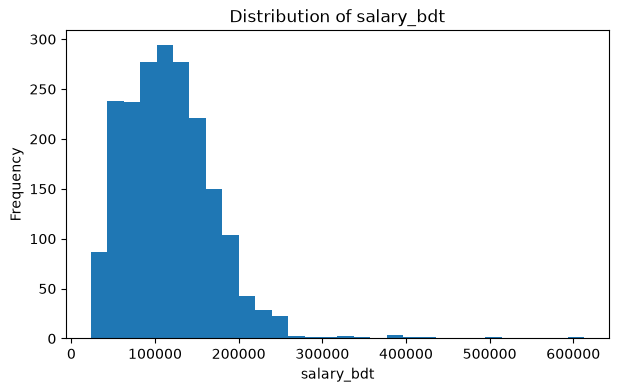

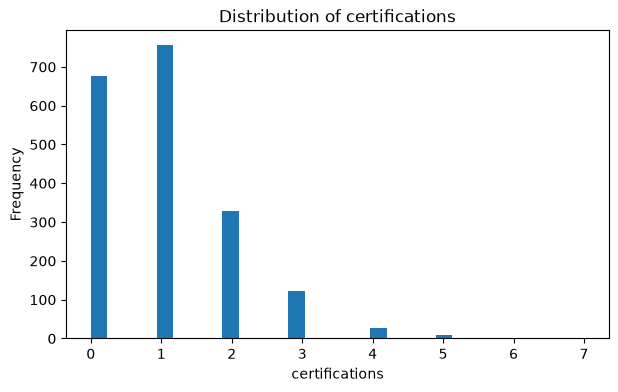

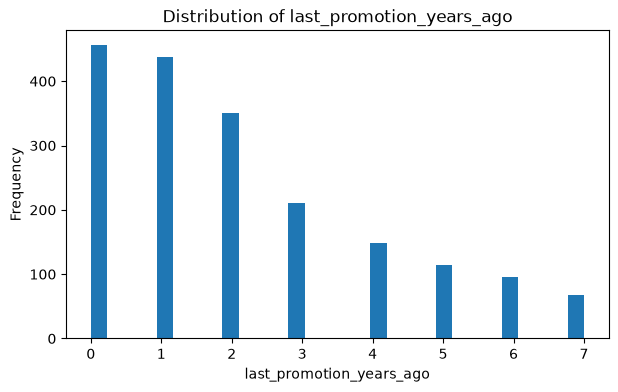

In [24]:
import matplotlib.pyplot as plt

# Highly and moderately skewed numerical columns
skewed_cols = [
    'salary_bdt',
    'certifications',
    'last_promotion_years_ago'
]

for col in skewed_cols:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [25]:
print("Skewness Interpretation:")

for col in skewed_cols:
    value = df[col].skew()

    if abs(value) < 0.5:
        interpretation = "Approximately symmetric"
    elif abs(value) < 1:
        interpretation = "Moderately skewed"
    else:
        interpretation = "Highly skewed"

    print(f"{col}: {value:.3f} → {interpretation}")

Skewness Interpretation:
salary_bdt: 1.569 → Highly skewed
certifications: 1.079 → Highly skewed
last_promotion_years_ago: 0.866 → Moderately skewed


In [26]:
# Log Transformation

df["salary_log"] = np.log1p(df["salary_bdt"])

print("Original Salary Skewness:")
print(df["salary_bdt"].skew())

print("\nLog Transformed Salary Skewness:")
print(df["salary_log"].skew())


Original Salary Skewness:
1.5687282207057276

Log Transformed Salary Skewness:
-0.3584970689414814


In [27]:
# Square Root Transformation

df["salary_sqrt"] = np.sqrt(df["salary_bdt"])

print("Original Salary Skewness:")
print(df["salary_bdt"].skew())

print("\nSquare Root Transformed Salary Skewness:")
print(df["salary_sqrt"].skew())

Original Salary Skewness:
1.5687282207057276

Square Root Transformed Salary Skewness:
0.4006275600116855


In [28]:
# Log Transformation - Certifications

df["certifications_log"] = np.log1p(df["certifications"])

print("Original Certifications Skewness:")
print(df["certifications"].skew())

print("\nLog Transformed Certifications Skewness:")
print(df["certifications_log"].skew())

Original Certifications Skewness:
1.0791993181751718

Log Transformed Certifications Skewness:
0.11778649587372604


In [29]:
# Square Root Transformation - Certifications

df["certifications_sqrt"] = np.sqrt(df["certifications"])

print("Original Certifications Skewness:")
print(df["certifications"].skew())

print("\nSquare Root Transformed Certifications Skewness:")
print(df["certifications_sqrt"].skew())


Original Certifications Skewness:
1.0791993181751718

Square Root Transformed Certifications Skewness:
-0.11633030962541129


In [30]:
# Log Transformation - Last Promotion

df["promotion_log"] = np.log1p(df["last_promotion_years_ago"])

print("Original Last Promotion Skewness:")
print(df["last_promotion_years_ago"].skew())

print("\nLog Transformed Last Promotion Skewness:")
print(df["promotion_log"].skew())

Original Last Promotion Skewness:
0.8660458851715843

Log Transformed Last Promotion Skewness:
-0.05676268872207766


In [31]:
# Square Root Transformation - Last Promotion

df["promotion_sqrt"] = np.sqrt(df["last_promotion_years_ago"])

print("Original Last Promotion Skewness:")
print(df["last_promotion_years_ago"].skew())

print("\nSquare Root Transformed Last Promotion Skewness:")
print(df["promotion_sqrt"].skew())

Original Last Promotion Skewness:
0.8660458851715843

Square Root Transformed Last Promotion Skewness:
-0.1709403418202141


In [32]:
# Final Transformation Comparison

final_comparison = pd.DataFrame({
    "Column": [
        "salary_bdt",
        "certifications",
        "last_promotion_years_ago"
    ],
    
    "Original Skewness": [
        df["salary_bdt"].skew(),
        df["certifications"].skew(),
        df["last_promotion_years_ago"].skew()
    ],
    
    "Log Skewness": [
        df["salary_log"].skew(),
        df["certifications_log"].skew(),
        df["promotion_log"].skew()
    ],
    
    "Square Root Skewness": [
        df["salary_sqrt"].skew(),
        df["certifications_sqrt"].skew(),
        df["promotion_sqrt"].skew()
    ]
})

final_comparison.round(4)

,Column,Original Skewness,Log Skewness,Square Root Skewness
0,salary_bdt,1.5687,-0.3585,0.4006
1,certifications,1.0792,0.1178,-0.1163
2,last_promotion_years_ago,0.8660,-0.0568,-0.1709


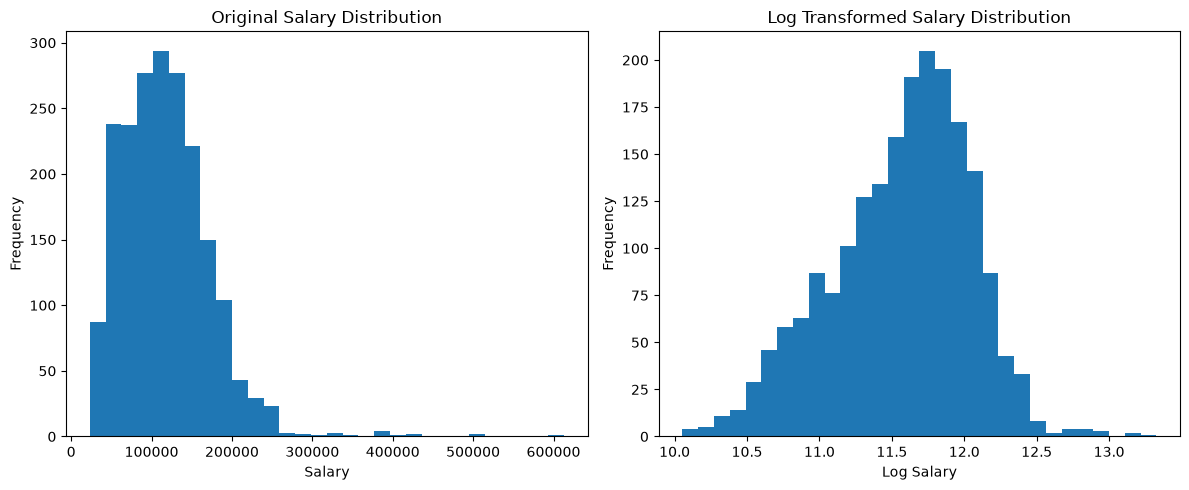

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df["salary_bdt"].dropna(), bins=30)
plt.title("Original Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(df["salary_log"].dropna(), bins=30)
plt.title("Log Transformed Salary Distribution")
plt.xlabel("Log Salary")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

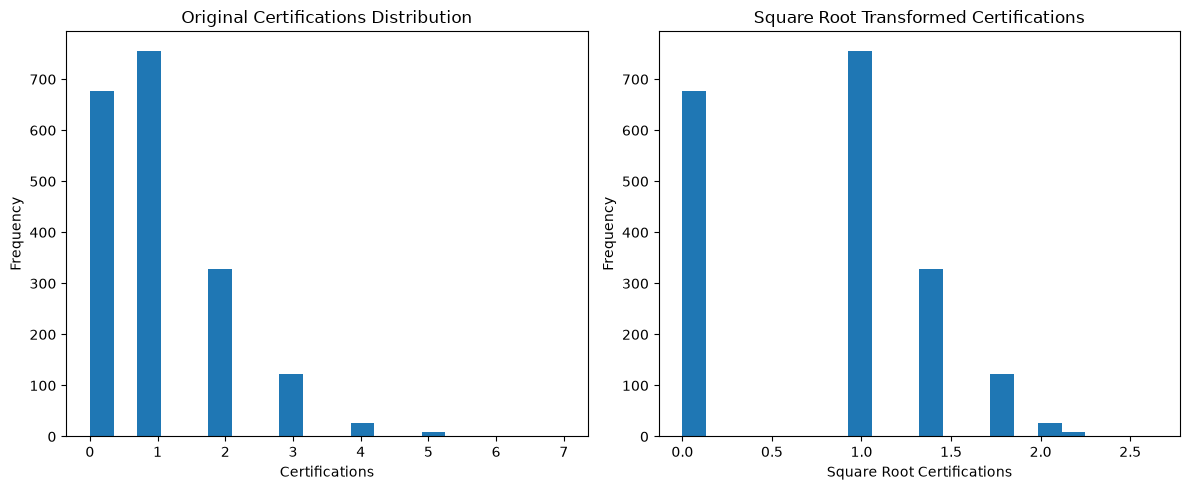

In [34]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df["certifications"].dropna(), bins=20)
plt.title("Original Certifications Distribution")
plt.xlabel("Certifications")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(df["certifications_sqrt"].dropna(), bins=20)
plt.title("Square Root Transformed Certifications")
plt.xlabel("Square Root Certifications")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

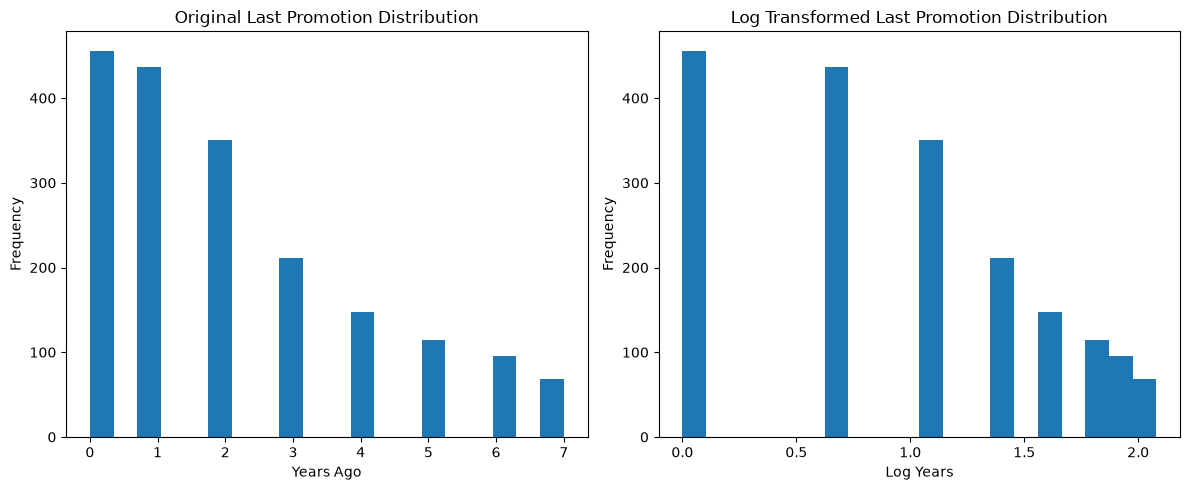

In [35]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df["last_promotion_years_ago"].dropna(), bins=20)
plt.title("Original Last Promotion Distribution")
plt.xlabel("Years Ago")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(df["promotion_log"].dropna(), bins=20)
plt.title("Log Transformed Last Promotion Distribution")
plt.xlabel("Log Years")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()